<a href="https://colab.research.google.com/github/SreeHarshaGudise/SocialNetworkAdsClassifier/blob/KnnClassifierExperiment/KnnClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("/content/drive/MyDrive/SocialAdsClassification/Social_Network_Ads.csv")

In [3]:
data.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [4]:
X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

In [6]:
X.shape
y.shape

(400,)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

In [9]:
X_train.shape

(320, 2)

In [10]:
y_train.shape

(320,)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
k = np.sqrt(len(X_train))

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
knn = KNeighborsClassifier(n_neighbors=int(k))

In [18]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=17)

In [19]:
y_pred = knn.predict(X_test)

In [20]:
y_pred.shape

(80,)

In [21]:
y_test.shape

(80,)

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score
accuracy_score(y_test,y_pred)

0.9125

In [23]:
confusion_matrix(y_test,y_pred)

array([[44,  4],
       [ 3, 29]])

In [25]:
# finding k in train and error method

accuracy=[]

for i in range(1,26):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  accuracy.append(accuracy_score(y_test,y_pred))

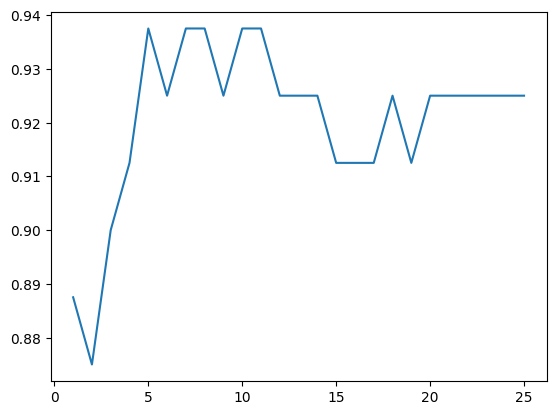

In [26]:
plt.plot(range(1,26),accuracy)